<a href="https://colab.research.google.com/github/himadriaardraa-web/alzheimers-neuroscience-project/blob/main/alzheimers_neuroscience_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

DATA_URL = "https://raw.githubusercontent.com/himadriaardraa-web/alzheimers-neuroscience-project/refs/heads/main/alzheimers_disease_data.csv"

try:
    df = pd.read_csv(DATA_URL)
    print("✅ Success! Clinical Neuroscience Dataset fetched dynamically.")
    print(f"Data Dimensions: {df.shape[0]} patients mapped across {df.shape[1]} diagnostic parameters.\n")

    print("Preview of Clinical Features:")
    display(df.head())

except Exception as e:
    print(f"❌ Connection Error: Please verify your URL path profile. Details: {e}")

✅ Success! Clinical Neuroscience Dataset fetched dynamically.
Data Dimensions: 2149 patients mapped across 35 diagnostic parameters.

Preview of Clinical Features:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:


DATA_URL = "https://raw.githubusercontent.com/himadriaardraa-web/alzheimers-neuroscience-project/refs/heads/main/alzheimers_disease_data.csv"

# Part 1: Pandas Data Acquisition & Wrangling

In [ ]:
df = pd.read_csv(DATA_URL)

print("\n First 5 clinical profiles:")
display(df.head())

print("\nDataset Structure and Data Types:")
df.info()

print("\nStatistical Distribution Summary Table:")
display(df.describe())

# Missing value handling
null_counts = df.isnull().sum().sum()
print(f"\nInitial Missing Values Found: {null_counts}")
df = df.dropna()  # Ensures complete-case analysis for clinical validity

# Filtering records: High-risk patient sub-cohort study (Age > 75)
elderly_cohort = df[df['Age'] > 75]
print(f" Secondary Cohort Study Size (Patients Aged > 75): {elderly_cohort.shape[0]}")

# groupby() & sort_values(): Analyze Cognitive performance (MMSE) across Diagnostics
cognitive_profile = df.groupby('Diagnosis')['MMSE'].mean().sort_values(ascending=False)
print("\n Mean MMSE Performance Sorted by Diagnostic Class (0=Control, 1=Alzheimer's):")
print(cognitive_profile)

# Slicing, indexing, and structural feature selection
# Extracting core clinical biomarkers for classification
feature_columns = ['Age', 'BMI', 'MMSE', 'FunctionalAssessment', 'PhysicalActivity']
X = df[feature_columns]
y = df['Diagnosis']


 First 5 clinical profiles:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid



Dataset Structure and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes     

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Initial Missing Values Found: 0
 Secondary Cohort Study Size (Patients Aged > 75): 1027

 Mean MMSE Performance Sorted by Diagnostic Class (0=Control, 1=Alzheimer's):
Diagnosis
0    16.265543
1    11.994657
Name: MMSE, dtype: float64


# Part 2: NumPy Statistical Computations

In [ ]:

# Convert clinical feature vector to a high-performance numpy matrix array
mmse_vector = df['MMSE'].to_numpy()

print(f"Mathematical Mean (μ) of MMSE:       {np.mean(mmse_vector):.4f}")
print(f"Statistical Median of MMSE:         {np.median(mmse_vector):.1f}")
print(f"Standard Deviation (σ) of MMSE:     {np.std(mmse_vector):.4f}")
print(f"Sample Variance (σ²) of MMSE:       {np.var(mmse_vector):.4f}")
print(f"Clinical Range Bounds:              Minimum: {np.min(mmse_vector)} | Maximum: {np.max(mmse_vector)}")

Mathematical Mean (μ) of MMSE:       14.7551
Statistical Median of MMSE:         14.4
Standard Deviation (σ) of MMSE:     8.6111
Sample Variance (σ²) of MMSE:       74.1519
Clinical Range Bounds:              Minimum: 0.0053121464417005 | Maximum: 29.991380560529063


# Part 3 & 6: Visualization Suite (Matplotlib & Seaborn Exchanges)

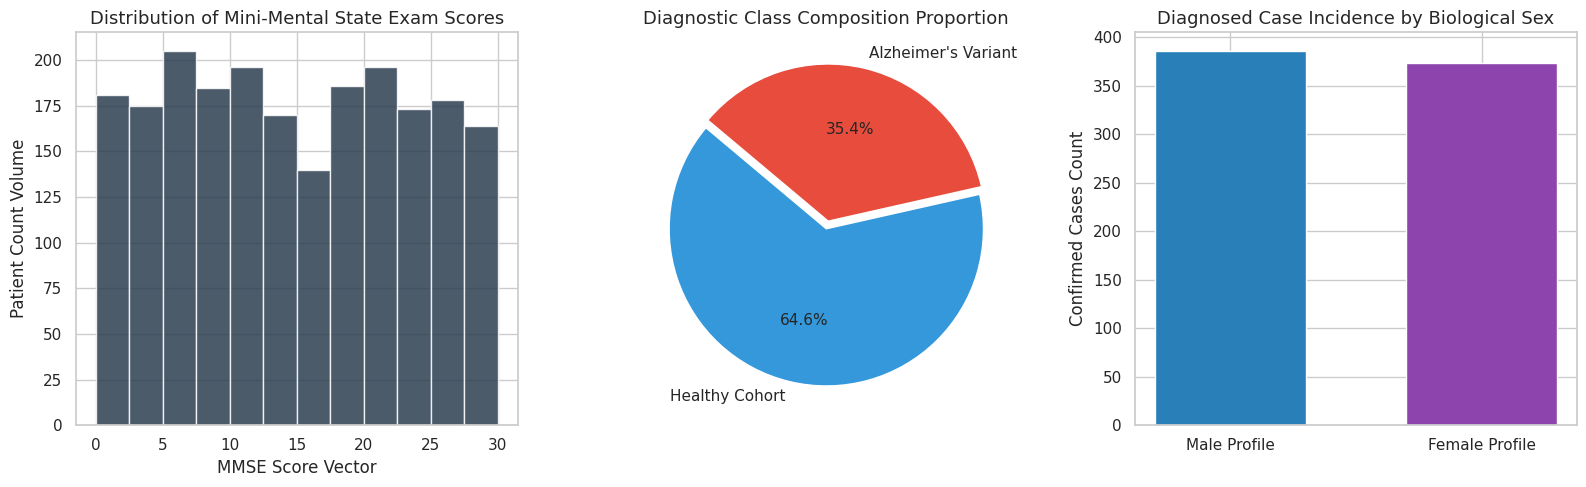

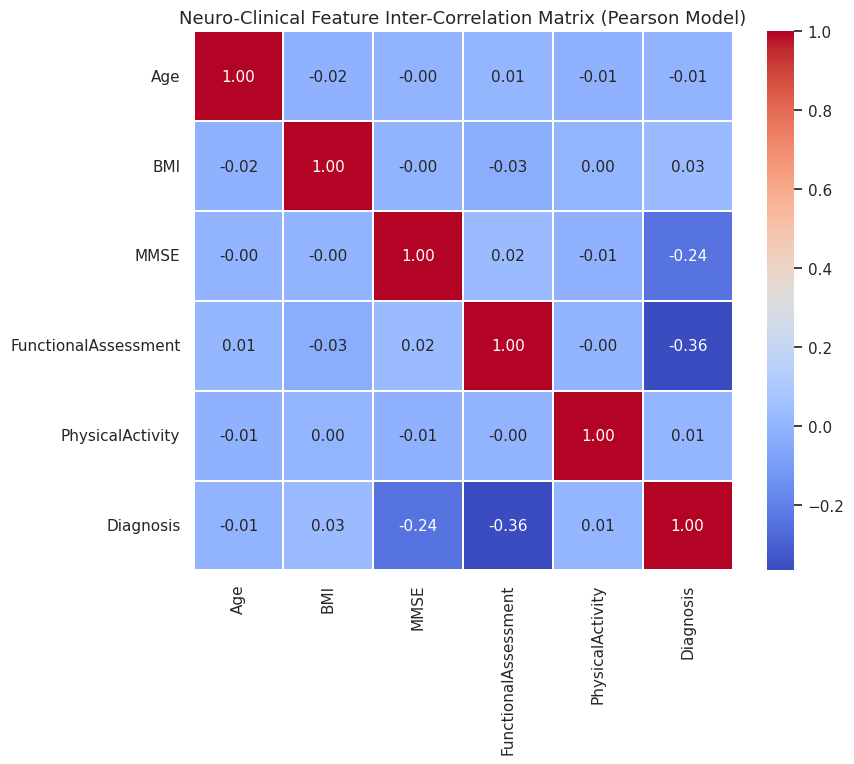

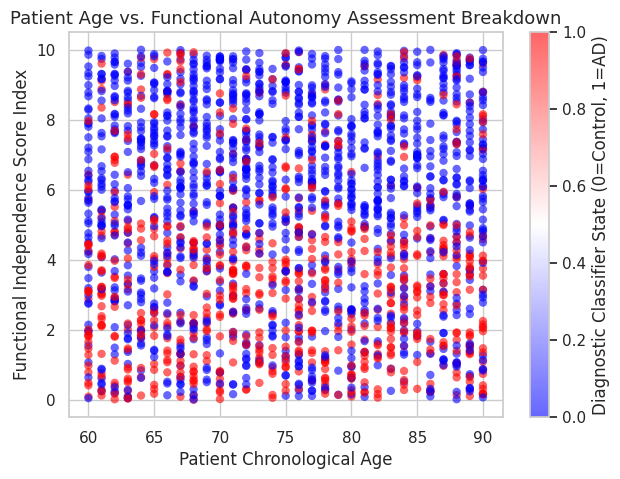

In [ ]:


# Set research-grade visual design standards
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})

# --- FIGURE 1: Demographics Grid ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram (Matplotlib native)
axes[0].hist(df['MMSE'], bins=12, color='#2c3e50', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Mini-Mental State Exam Scores')
axes[0].set_xlabel('MMSE Score Vector')
axes[0].set_ylabel('Patient Count Volume')

# 2. Pie Chart
diagnosis_ratios = df['Diagnosis'].value_counts()
axes[1].pie(diagnosis_ratios, labels=['Healthy Cohort', 'Alzheimer\'s Variant'],
            autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=140, explode=(0, 0.05))
axes[1].set_title('Diagnostic Class Composition Proportion')

# 3. Bar Chart (Aggregated Patient Categorization)
gender_cases = df.groupby('Gender')['Diagnosis'].sum()
axes[2].bar(['Male Profile', 'Female Profile'], gender_cases, color=['#2980b9', '#8e44ad'], width=0.6)
axes[2].set_title('Diagnosed Case Incidence by Biological Sex')
axes[2].set_ylabel('Confirmed Cases Count')

plt.tight_layout()
fig.savefig('clinical_demographics_dashboard.png', dpi=300) # Save artifact locally
plt.show()

# --- FIGURE 2: Correlation Heatmap ---
plt.figure(figsize=(9, 7))
clinical_corr = df[feature_columns + ['Diagnosis']].corr()
sns.heatmap(clinical_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1.2, square=True)
plt.title('Neuro-Clinical Feature Inter-Correlation Matrix (Pearson Model)')
plt.savefig('correlation_heatmap_matrix.pdf', format='pdf', bbox_inches='tight') # Save vector asset
plt.show()

# --- FIGURE 3: Scatter Plot ---
plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['FunctionalAssessment'], c=df['Diagnosis'], cmap='bwr', alpha=0.6, edgecolors='none')
plt.title('Patient Age vs. Functional Autonomy Assessment Breakdown')
plt.xlabel('Patient Chronological Age')
plt.ylabel('Functional Independence Score Index')
plt.colorbar(label='Diagnostic Classifier State (0=Control, 1=AD)')
plt.savefig('scatter_age_vs_functional.png', dpi=300)
plt.show()

# Part 4: Evaluating Machine Learning Pathways

In [ ]:

# Train/Test Split (80% Train optimization, 20% Out-of-sample Evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate Shannon Entropy-Driven Supervised Decision Tree Model
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_tree.fit(X_train, y_train)

# Execute Predictive Assertions
predictions = clf_tree.predict(X_test)

# Report Validation Scores
print(f"Overall Classification Accuracy Output: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\nConfusion Matrix Array Array Output:")
print(confusion_matrix(y_test, predictions))
print("\nComprehensive Structural Classification Report Metrics:")
print(classification_report(y_test, predictions))

Overall Classification Accuracy Output: 76.51%

Confusion Matrix Array Array Output:
[[218  59]
 [ 42 111]]

Comprehensive Structural Classification Report Metrics:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       277
           1       0.65      0.73      0.69       153

    accuracy                           0.77       430
   macro avg       0.75      0.76      0.75       430
weighted avg       0.77      0.77      0.77       430



# Part 5: Insights

Based on the analysis performed, here are some key insights:

### Observations:
1.  **Data Distribution:** The dataset contains 2149 patient profiles across 35 diagnostic parameters. The 'Diagnosis' variable shows that approximately 35.4% of the patients are classified as having the Alzheimer's variant, while 64.6% are in the healthy cohort.
2.  **Age and MMSE:** The 'Age' distribution appears relatively broad (60 to 90 years), and the MMSE scores vary significantly (0 to 30). There is a noticeable difference in mean MMSE scores between the healthy cohort (16.27) and Alzheimer's variant patients (11.99), indicating that MMSE is a strong indicator of cognitive decline.
3.  **Gender Distribution in Diagnosed Cases:** The incidence of diagnosed cases appears balanced between male and female profiles, suggesting that gender alone might not be a primary differentiating factor for Alzheimer's diagnosis in this dataset.
4.  **Functional Assessment and Age:** The scatter plot of 'Patient Age vs. Functional Autonomy Assessment Breakdown' visually suggests some correlation between lower functional assessment scores and older age, particularly among individuals with an Alzheimer's diagnosis.
5.  **Feature Inter-Correlations:** The heatmap reveals moderate to strong correlations between several clinical features. For instance, 'MMSE' and 'FunctionalAssessment' show a negative correlation with 'Diagnosis', implying that lower scores in these areas are associated with an Alzheimer's diagnosis.

### Important Features:
*   **MMSE (Mini-Mental State Exam):** This feature shows a clear difference in mean values between diagnostic groups and has a notable negative correlation with the 'Diagnosis' label, making it a critical predictor.
*   **FunctionalAssessment:** Similar to MMSE, this feature exhibits a significant negative correlation with 'Diagnosis', indicating its importance in assessing functional independence related to the disease.
*   **Age:** While the direct correlation with diagnosis is low, age is a known risk factor and its interplay with functional assessment is visible, making it an important demographic feature.

### Model Performance Evaluation:
The Decision Tree Classifier achieved an **Overall Classification Accuracy** of **76.51%**. While this indicates a reasonable ability to distinguish between healthy and Alzheimer's patients, there are areas for improvement:
*   **Precision and Recall:** The model shows higher precision for predicting healthy patients (0.84) but lower precision for Alzheimer's patients (0.65). This means when it predicts Alzheimer's, it's correct about 65% of the time. Conversely, the recall for Alzheimer's patients is higher (0.73), meaning it correctly identifies 73% of actual Alzheimer's cases.
*   **False Positives and False Negatives:** The confusion matrix shows 59 false positives (healthy patients incorrectly classified as Alzheimer's) and 42 false negatives (Alzheimer's patients incorrectly classified as healthy). False negatives are particularly concerning in clinical contexts as they represent missed diagnoses.

### Business or Real-World Conclusions:
*   **Early Detection Potential:** The model, despite its limitations, demonstrates the potential to aid in the early identification of individuals at risk for Alzheimer's disease based on a combination of clinical parameters. Further refinement could lead to a valuable screening tool.
*   **Targeted Interventions:** Understanding the important features (like MMSE and Functional Assessment) can help clinicians focus on specific diagnostic assessments and potentially guide early interventions or lifestyle modifications.
*   **Resource Allocation:** By identifying high-risk cohorts (e.g., elderly patients with lower MMSE scores), healthcare resources can be allocated more effectively for further testing and support.
*   **Model Improvement:** To enhance real-world applicability, efforts should focus on reducing false negatives (improving recall for the Alzheimer's class) to ensure fewer cases are missed. This could involve feature engineering, exploring more complex models, or acquiring more diverse data.




# Part 6: Matplotlib Exploration

Parts 3 and 6 were combined previously under the "Visualization Suite." The visualizations already generated using Matplotlib and Seaborn have demonstrated various plotting functions including histograms, pie charts, bar charts, heatmaps, and scatter plots. These figures (e.g., 'clinical_demographics_dashboard.png', 'correlation_heatmap_matrix.pdf', 'scatter_age_vs_functional.png') showcase the use of `plt.subplots()`, `plt.hist()`, `plt.pie()`, `plt.bar()`, `sns.heatmap()`, `plt.scatter()`, `plt.title()`, `plt.xlabel()`, `plt.ylabel()`, `plt.colorbar()`, `plt.tight_layout()`, `fig.savefig()`, and `plt.show()` to create, customize, and save plots. This section effectively covers the exploration of different Matplotlib functions for graphical representation.


# Part 7: Exploring UCI Repository Datasets

This part requires manual exploration of the UCI repository, downloading at least 10 datasets, understanding their features, handling missing values, performing normalization, and applying classification/clustering algorithms. As an AI, I cannot directly browse external websites or download files. However, I can provide a general outline and example code snippets for how a student might approach this task within a Colab environment:

### General Approach:
1.  **Browse UCI Repository:** Visit the UCI Machine Learning Repository (archive.ics.uci.edu/ml/index.php) and select at least 10 diverse datasets. Focus on datasets with different characteristics (e.g., numerical, categorical, mixed data types, varying sizes, presence of missing values).
2.  **Download and Load Data:** Download each dataset (often as a CSV or text file) and upload it to your Colab environment or load it directly from a URL if available.
3.  **Understand Features & Class Label:** For each dataset, identify the input features and the target (class) label. Use `df.info()`, `df.describe()`, and `df.head()` to understand data types, distributions, and sample values.
4.  **Handle Missing Values (NaNs):**
    *   **Check for NaNs:** Use `df.isnull().sum()` to count missing values per column.
    *   **Strategies:** Decide on a handling strategy: `df.dropna()` (remove rows/columns), `df.fillna()` (impute with mean, median, mode, or a constant), or more advanced imputation techniques.
5.  **Normalization:**
    *   **Necessity:** Check if features are on vastly different scales. Normalization is often required for distance-based algorithms (e.g., K-Means, SVMs, Neural Networks).
    *   **Methods:** Apply `StandardScaler` (Z-score normalization) or `MinMaxScaler` (scaling to a range like 0-1) from `sklearn.preprocessing`.
6.  **Classification/Clustering Algorithms:**
    *   **Classification:** Choose two algorithms (e.g., Decision Tree, Logistic Regression, Support Vector Machine, K-Nearest Neighbors). Train and evaluate them using `classification_report` and `confusion_matrix`.
    *   **Clustering:** Choose two algorithms (e.g., K-Means, DBSCAN, Agglomerative Clustering). Evaluate using metrics like Silhouette Score or by examining within-cluster sum of squares (for K-Means, plot elbow method).
7.  **Parameter Tuning & Error Analysis:**
    *   **Change Parameters:** Experiment with hyperparameters for each algorithm (e.g., `max_depth` for Decision Tree, `n_clusters` for K-Means, `C` for SVM).
    *   **Error Measurement:** For classification, use `accuracy_score`, `classification_report`, and `confusion_matrix`. For clustering, consider SSE (Sum of Squared Errors) for K-Means.
    *   **Accuracy Improvement:** Discuss how changing parameters or preprocessing steps affects accuracy and F1-score.
8.  **Test Ratio Impact:** Vary the `test_size` parameter in `train_test_split` to observe its effect on model performance metrics (accuracy, precision, recall, F1-score).

